# CityPulse — Prédiction météo intelligente

In [7]:
# ============================================================
# PROJET      : CityPulse — Prédiction météo intelligente
# RÔLE        : DAN — Data Analyst
# AUTEUR      : [Ton nom]
# DATE        : 18/03/2026
# ============================================================
#
# DESCRIPTION :
# Prédiction de la température pour les 6 prochaines heures
# avec indicateur de confiance basé sur le R².
#
# VILLES      : Bordeaux, Lille, Lyon, Marseille, Paris
# SOURCE      : Open-Meteo API (gratuit, sans clé)
# HORIZONS    : +1h, +2h, +3h, +4h, +5h, +6h
#
# MODÈLES TESTÉS :
#   V2 — Régression Linéaire  (baseline)
#   V3 — Random Forest        (100 arbres)
#   V4 — XGBoost              (200 arbres)
#
# MÉTRIQUE DE CONFIANCE :
#   Basée sur le R² de chaque horizon
#   +1h → R² élevé → confiance haute
#   +6h → R² plus faible → confiance plus basse
# ============================================================

# IMPORTS

In [8]:
# ============================================================
# IMPORTS
# ============================================================

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Modèles ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Métriques d'évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilitaires
from datetime import timedelta
import json

import pickle
import os
print("Imports OK ✓")

Imports OK ✓


# CHARGEMENT DES DONNÉES

In [9]:
# ============================================================
# CHARGEMENT DES DONNÉES
# Source  : Open-Meteo API (gratuit, sans clé)
# Période : 2023-01-01 → 2026-03-17
# Villes  : Lyon, Paris, Marseille, Bordeaux, Lille
# ============================================================

import requests
import pandas as pd

# --- Dictionnaire des villes ---
VILLES = {
    "Lyon"      : {"latitude": 45.7640, "longitude":  4.8357},
    "Paris"     : {"latitude": 48.8566, "longitude":  2.3522},
    "Marseille" : {"latitude": 43.2965, "longitude":  5.3698},
    "Bordeaux"  : {"latitude": 44.8378, "longitude": -0.5792},
    "Lille"     : {"latitude": 50.6292, "longitude":  3.0573},
}

# --- Fonction de récupération pour une ville ---
def recuperer_meteo_historique(latitude, longitude, ville, start_date, end_date):
    """
    Récupère les données météo horaires depuis Open-Meteo.
    Retourne un DataFrame pandas prêt pour le ML.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude"  : latitude,
        "longitude" : longitude,
        "start_date": start_date,
        "end_date"  : end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "wind_speed_10m",
            "cloud_cover",
            "precipitation",
        ],
        "timezone": "Europe/Paris"
    }

    print(f"Récupération des données pour {ville}...")
    response = requests.get(url, params=params)

    if response.status_code != 200:
        raise Exception(f"Erreur API : {response.status_code} — {response.text}")

    data   = response.json()
    hourly = data["hourly"]

    df = pd.DataFrame({
        "datetime"     : pd.to_datetime(hourly["time"]),
        "temperature"  : hourly["temperature_2m"],
        "humidite"     : hourly["relative_humidity_2m"],
        "pression"     : hourly["surface_pressure"],
        "vent"         : hourly["wind_speed_10m"],
        "nuages"       : hourly["cloud_cover"],
        "precipitation": hourly["precipitation"],
    })

    df = df.set_index("datetime")
    df["ville"] = ville

    print(f"✓ {len(df)} lignes récupérées ({df.index.min()} → {df.index.max()})")
    return df


# --- Fonction de récupération pour toutes les villes ---
def recuperer_toutes_les_villes(villes, start_date, end_date):
    """
    Récupère les données pour toutes les villes du dictionnaire.
    Retourne un DataFrame fusionné.
    """
    frames = []
    for nom, coords in villes.items():
        df = recuperer_meteo_historique(
            latitude   = coords["latitude"],
            longitude  = coords["longitude"],
            ville      = nom,
            start_date = start_date,
            end_date   = end_date,
        )
        frames.append(df)

    df_all = pd.concat(frames)
    print(f"\n✅ Total : {len(df_all)} lignes, {df_all['ville'].nunique()} villes")
    return df_all


# --- Lancement de la récupération ---
START = "2023-01-01"
END   = "2026-03-17"

df_brut = recuperer_toutes_les_villes(VILLES, START, END)

# --- Vérifications ---
print(f"\nShape    : {df_brut.shape}")
print(f"Période  : {df_brut.index.min()} → {df_brut.index.max()}")
print(f"Villes   : {df_brut['ville'].unique()}")
print(f"\nValeurs manquantes :")
print(df_brut.isnull().sum())

Récupération des données pour Lyon...
✓ 28128 lignes récupérées (2023-01-01 00:00:00 → 2026-03-17 23:00:00)
Récupération des données pour Paris...
✓ 28128 lignes récupérées (2023-01-01 00:00:00 → 2026-03-17 23:00:00)
Récupération des données pour Marseille...
✓ 28128 lignes récupérées (2023-01-01 00:00:00 → 2026-03-17 23:00:00)
Récupération des données pour Bordeaux...
✓ 28128 lignes récupérées (2023-01-01 00:00:00 → 2026-03-17 23:00:00)
Récupération des données pour Lille...
✓ 28128 lignes récupérées (2023-01-01 00:00:00 → 2026-03-17 23:00:00)

✅ Total : 140640 lignes, 5 villes

Shape    : (140640, 7)
Période  : 2023-01-01 00:00:00 → 2026-03-17 23:00:00
Villes   : <StringArray>
['Lyon', 'Paris', 'Marseille', 'Bordeaux', 'Lille']
Length: 5, dtype: str

Valeurs manquantes :
temperature      0
humidite         0
pression         0
vent             0
nuages           0
precipitation    0
ville            0
dtype: int64


## FEATURE ENGINEERING

In [10]:
# ============================================================
# FEATURE ENGINEERING
# Calcul par ville séparément pour éviter les mélanges
#
# Lags courts  : tendance des dernières heures
# Lags moyens  : cycles importants (6h, 12h, 24h)
# Lags longs   : tendance sur 2 jours (36h, 48h)
# Fenêtres     : moyenne et stabilité météo
# Cycliques    : heure et mois encodés en sin/cos
# Cibles       : température dans +1h à +6h uniquement
# ============================================================

dfs = []

for ville in df_brut["ville"].unique():
    df_ville = df_brut[df_brut["ville"] == ville].copy()
    df_ville = df_ville.sort_index()

    # --- Lags courts ---
    df_ville["temp_lag_1h"]  = df_ville["temperature"].shift(1)
    df_ville["temp_lag_2h"]  = df_ville["temperature"].shift(2)
    df_ville["temp_lag_3h"]  = df_ville["temperature"].shift(3)

    # --- Lags moyens ---
    df_ville["temp_lag_6h"]  = df_ville["temperature"].shift(6)
    df_ville["temp_lag_12h"] = df_ville["temperature"].shift(12)
    df_ville["temp_lag_24h"] = df_ville["temperature"].shift(24)

    # --- Lags longs ---
    df_ville["temp_lag_36h"] = df_ville["temperature"].shift(36)
    df_ville["temp_lag_48h"] = df_ville["temperature"].shift(48)

    # --- Fenêtres glissantes ---
    df_ville["temp_moy_6h"]  = df_ville["temperature"].rolling(6).mean()
    df_ville["temp_moy_12h"] = df_ville["temperature"].rolling(12).mean()
    df_ville["temp_std_12h"] = df_ville["temperature"].rolling(12).std()

    # --- Cibles : +1h à +6h uniquement ---
    for h in range(1, 7):
        df_ville[f"cible_{h}h"] = df_ville["temperature"].shift(-h)

    dfs.append(df_ville)

# --- Fusionner toutes les villes ---
df_final = pd.concat(dfs)

# --- Encoder la ville en colonnes binaires ---
df_final = pd.get_dummies(df_final, columns=["ville"])

# --- Supprimer les lignes incomplètes ---
df_final = df_final.dropna()

# --- Trier par date ---
df_final = df_final.sort_index()

# --- Variables temporelles cycliques ---
df_final["heure_sin"] = np.sin(2 * np.pi * df_final.index.hour / 24)
df_final["heure_cos"] = np.cos(2 * np.pi * df_final.index.hour / 24)
df_final["mois_sin"]  = np.sin(2 * np.pi * df_final.index.month / 12)
df_final["mois_cos"]  = np.cos(2 * np.pi * df_final.index.month / 12)

# --- Vérifications ---
print(f"Dataset final : {df_final.shape}")
print(f"Période       : {df_final.index.min()} → {df_final.index.max()}")
print(f"Colonnes      : {df_final.columns.tolist()}")

Dataset final : (140370, 32)
Période       : 2023-01-03 00:00:00 → 2026-03-17 17:00:00
Colonnes      : ['temperature', 'humidite', 'pression', 'vent', 'nuages', 'precipitation', 'temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_lag_6h', 'temp_lag_12h', 'temp_lag_24h', 'temp_lag_36h', 'temp_lag_48h', 'temp_moy_6h', 'temp_moy_12h', 'temp_std_12h', 'cible_1h', 'cible_2h', 'cible_3h', 'cible_4h', 'cible_5h', 'cible_6h', 'ville_Bordeaux', 'ville_Lille', 'ville_Lyon', 'ville_Marseille', 'ville_Paris', 'heure_sin', 'heure_cos', 'mois_sin', 'mois_cos']


## SPLIT CHRONOLOGIQUE

In [11]:
# ============================================================
# SPLIT CHRONOLOGIQUE
# On ne mélange jamais les données temporelles
#
# Train      : 2023-01-03 → 2025-01-01  (~62%)
# Validation : 2025-01-01 → 2025-10-01  (~23%)
# Test final : 2025-10-01 → 2026-03-17  (~15%)
# ============================================================

split_train      = "2025-01-01"
split_validation = "2025-10-01"

# --- Liste des features ---
features = [
    # Lags courts
    "temp_lag_1h", "temp_lag_2h", "temp_lag_3h",
    # Lags moyens
    "temp_lag_6h", "temp_lag_12h", "temp_lag_24h",
    # Lags longs
    "temp_lag_36h", "temp_lag_48h",
    # Fenêtres glissantes
    "temp_moy_6h", "temp_moy_12h", "temp_std_12h",
    # Variables météo
    "humidite", "pression", "vent", "nuages",
    # Variables temporelles cycliques
    "heure_sin", "heure_cos", "mois_sin", "mois_cos",
    # Encodage des villes
    "ville_Bordeaux", "ville_Lille", "ville_Lyon",
    "ville_Marseille", "ville_Paris"
]

# --- Séparation chronologique ---
X_train = df_final[df_final.index < split_train][features]
X_val   = df_final[(df_final.index >= split_train) &
                   (df_final.index < split_validation)][features]
X_test  = df_final[df_final.index >= split_validation][features]

# --- Vérifications ---
print(f"Train      : {len(X_train)} lignes")
print(f"Validation : {len(X_val)} lignes")
print(f"Test final : {len(X_test)} lignes")
print(f"Features   : {len(features)}")

Train      : 87480 lignes
Validation : 32760 lignes
Test final : 20130 lignes
Features   : 24


# FONCTIONS UTILITAIRES

In [12]:
# ============================================================
# FONCTIONS UTILITAIRES
# Réutilisées par toutes les versions de modèles
# ============================================================

def entrainer_modeles(modele_classe, params, X_train, df_final,
                      split_train, nom_version):
    """
    Entraîne 6 modèles indépendants (un par horizon +1h à +6h).
    Retourne un dictionnaire {horizon: modele_entraîné}.
    """
    modeles = {}
    print(f"Entraînement {nom_version}...")

    for h in range(1, 7):
        y_train = df_final[df_final.index < split_train][f"cible_{h}h"]
        modele  = modele_classe(**params)
        modele.fit(X_train, y_train)
        modeles[h] = modele
        print(f"  +{h}h entraîné ✓")

    print(f"6 modèles {nom_version} entraînés ✅")
    return modeles


def evaluer_modeles(modeles, X_eval, df_final,
                    date_debut, date_fin, nom_version):
    """
    Calcule MAE, RMSE, R² pour chaque horizon.
    Retourne un dictionnaire des résultats.
    """
    print(f"\n=== {nom_version} ===")
    print(f"{'Horizon':<10} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
    print("-" * 38)

    resultats = {}
    for h in range(1, 7):
        # Filtrer par période
        if date_fin:
            mask = ((df_final.index >= date_debut) &
                    (df_final.index < date_fin))
        else:
            mask = df_final.index >= date_debut

        y_eval = df_final[mask][f"cible_{h}h"]
        pred   = modeles[h].predict(X_eval)

        mae  = mean_absolute_error(y_eval, pred)
        rmse = np.sqrt(mean_squared_error(y_eval, pred))
        r2   = r2_score(y_eval, pred)

        resultats[h] = {"MAE": round(mae, 3),
                        "RMSE": round(rmse, 3),
                        "R2": round(r2, 3)}

        print(f"+{h}h{'':<7} {mae:>7.2f}°C {rmse:>7.2f}°C {r2:>8.3f}")

    return resultats


def visualiser_modele(modeles, df_final, features, split_train,
                      split_validation, horizon, nom_version):
    """
    Affiche scatter + courbe temporelle pour Lyon.
    Permet de vérifier visuellement la qualité du modèle.
    """
    mask = ((df_final.index >= split_train) &
            (df_final.index < split_validation) &
            (df_final["ville_Lyon"] == True))

    y_val = df_final[mask][f"cible_{horizon}h"]
    X_val = df_final[mask][features]
    pred  = modeles[horizon].predict(X_val)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- Scatter ---
    axes[0].scatter(y_val, pred, color="steelblue", alpha=0.2)
    axes[0].plot([y_val.min(), y_val.max()],
                 [y_val.min(), y_val.max()],
                 color="red", linewidth=2, label="Prédiction parfaite")
    axes[0].set_title(f"Scatter — {nom_version} à +{horizon}h")
    axes[0].set_xlabel("Température réelle (°C)")
    axes[0].set_ylabel("Température prédite (°C)")
    axes[0].legend()
    axes[0].grid(True)

    # --- Courbe temporelle ---
    axes[1].plot(y_val.index[:500], y_val.values[:500],
                 color="steelblue", label="Réel", linewidth=1.5)
    axes[1].plot(y_val.index[:500], pred[:500],
                 color="orange", label="Prédit", linewidth=1.5, alpha=0.8)
    axes[1].set_title(f"Courbe — {nom_version} à +{horizon}h")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Température (°C)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(f"{nom_version} — Lyon à +{horizon}h", fontsize=14)
    plt.tight_layout()
    plt.show()


def predire_6h(modeles, df_final, features, ville, r2_par_horizon):
    """
    Prédit la température pour les 6 prochaines heures.
    Retourne un dictionnaire avec températures et indicateur de confiance.
    """
    # Dernière ligne connue pour la ville
    col_ville      = f"ville_{ville}"
    derniere_ligne = df_final[df_final[col_ville] == True].sort_index().iloc[[-1]][features]
    heure_depart   = derniere_ligne.index[0]

    predictions = []
    for h in range(1, 7):
        # float() convertit float32 → float standard compatible JSON
        temp      = round(float(modeles[h].predict(derniere_ligne)[0]), 1)
        confiance = round(r2_par_horizon[h] * 100, 1)
        heure     = heure_depart + timedelta(hours=h)

        predictions.append({
            "heure"      : heure.strftime("%d/%m %Hh"),
            "temperature": temp,
            "confiance"  : confiance
        })

    return {
        "ville"     : ville,
        "base"      : heure_depart.strftime("%d/%m/%Y %Hh"),
        "previsions": predictions
    }

print("Fonctions utilitaires chargées ✓")

Fonctions utilitaires chargées ✓


## VERSION 1 — RÉGRESSION LINÉAIRE

Entraînement Régression Linéaire...
  +1h entraîné ✓
  +2h entraîné ✓
  +3h entraîné ✓
  +4h entraîné ✓
  +5h entraîné ✓
  +6h entraîné ✓
6 modèles Régression Linéaire entraînés ✅

=== V1 — Régression Linéaire — Validation ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.73°C    0.96°C    0.985
+2h           1.07°C    1.38°C    0.970
+3h           1.35°C    1.74°C    0.952
+4h           1.58°C    2.03°C    0.934
+5h           1.74°C    2.24°C    0.920
+6h           1.84°C    2.38°C    0.910

=== V1 — Régression Linéaire — Test Final ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.67°C    0.85°C    0.969
+2h           0.99°C    1.24°C    0.935
+3h           1.26°C    1.57°C    0.895
+4h           1.48°C    1.83°C    0.857
+5h           1.63°C    2.03°C    0.824
+6h           1.73°C    2.16°C    0.802


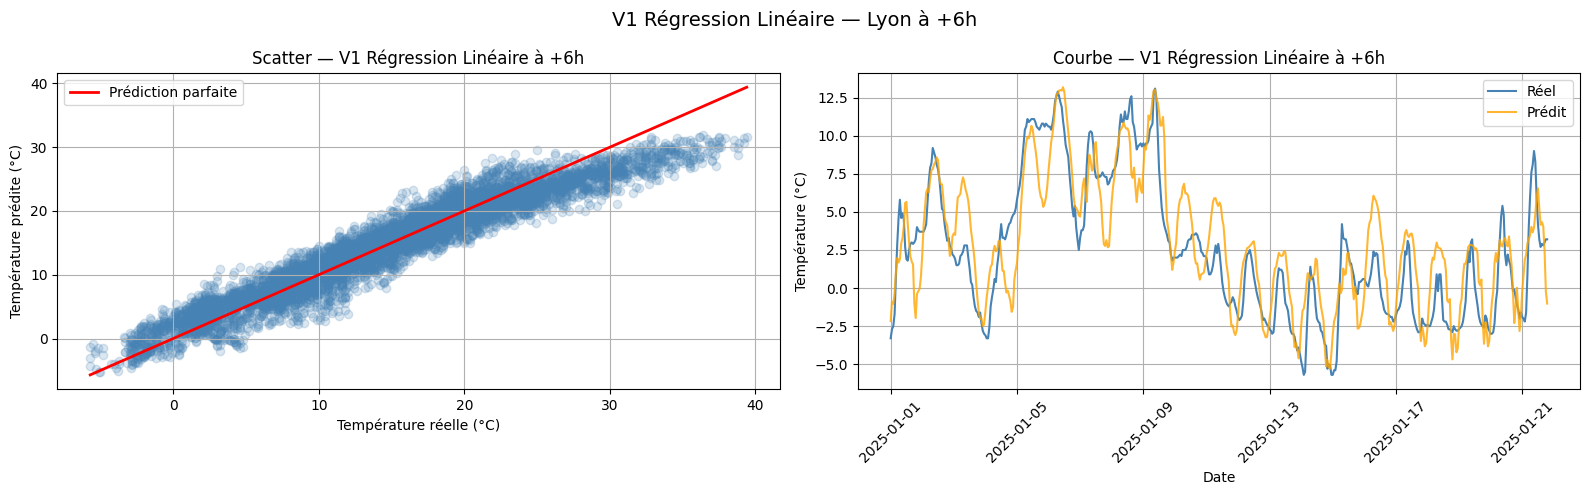

In [13]:
# ============================================================
# VERSION 1 — RÉGRESSION LINÉAIRE
# Modèle de référence (baseline)
# Simple, rapide, interprétable
# ============================================================

# --- Entraînement ---
modeles_v1 = entrainer_modeles(
    LinearRegression, {},
    X_train, df_final, split_train,
    "Régression Linéaire"
)

# --- Validation ---
resultats_v1_val = evaluer_modeles(
    modeles_v1, X_val, df_final,
    split_train, split_validation,
    "V1 — Régression Linéaire — Validation"
)

# --- Test final ---
resultats_v1_test = evaluer_modeles(
    modeles_v1, X_test, df_final,
    split_validation, None,
    "V1 — Régression Linéaire — Test Final"
)

# --- Graphique ---
visualiser_modele(
    modeles_v1, df_final, features,
    split_train, split_validation, 6,
    "V1 Régression Linéaire"
)

## VERSION 2 — RANDOM FOREST

Entraînement Random Forest...
  +1h entraîné ✓
  +2h entraîné ✓
  +3h entraîné ✓
  +4h entraîné ✓
  +5h entraîné ✓
  +6h entraîné ✓
6 modèles Random Forest entraînés ✅

=== V2 — Random Forest — Validation ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.64°C    0.87°C    0.988
+2h           0.85°C    1.14°C    0.979
+3h           1.03°C    1.38°C    0.970
+4h           1.18°C    1.56°C    0.961
+5h           1.29°C    1.71°C    0.953
+6h           1.39°C    1.84°C    0.946

=== V2 — Random Forest — Test Final ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.58°C    0.77°C    0.975
+2h           0.77°C    1.01°C    0.956
+3h           0.93°C    1.22°C    0.937
+4h           1.05°C    1.38°C    0.919
+5h           1.16°C    1.52°C    0.902
+6h           1.29°C    1.66°C    0.882


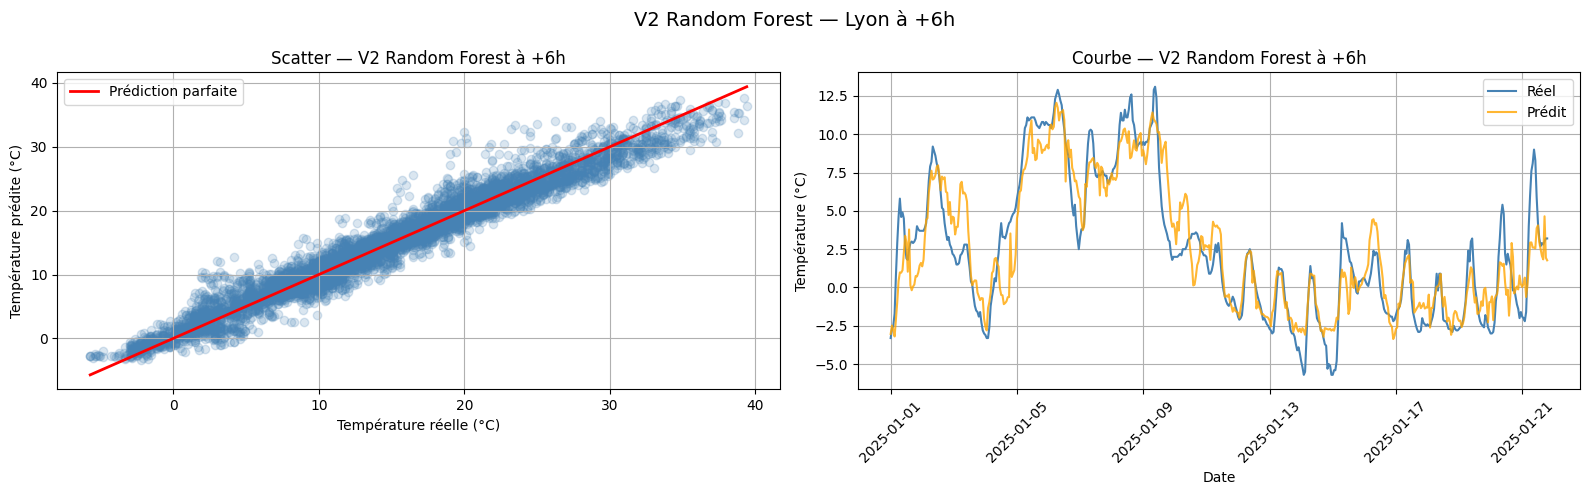

In [14]:
# ============================================================
# VERSION 2 — RANDOM FOREST
# 100 arbres de décision
# Capture les relations non linéaires
# Meilleur que la régression linéaire sur les patterns complexes
# ============================================================

# --- Entraînement ---
modeles_v2 = entrainer_modeles(
    RandomForestRegressor,
    {"n_estimators": 100, "n_jobs": -1, "random_state": 42},
    X_train, df_final, split_train,
    "Random Forest"
)

# --- Validation ---
resultats_v2_val = evaluer_modeles(
    modeles_v2, X_val, df_final,
    split_train, split_validation,
    "V2 — Random Forest — Validation"
)

# --- Test final ---
resultats_v2_test = evaluer_modeles(
    modeles_v2, X_test, df_final,
    split_validation, None,
    "V2 — Random Forest — Test Final"
)

# --- Graphique ---
visualiser_modele(
    modeles_v2, df_final, features,
    split_train, split_validation, 6,
    "V2 Random Forest"
)

## VERSION 3 — XGBOOST

Entraînement XGBoost...
  +1h entraîné ✓
  +2h entraîné ✓
  +3h entraîné ✓
  +4h entraîné ✓
  +5h entraîné ✓
  +6h entraîné ✓
6 modèles XGBoost entraînés ✅

=== V3 — XGBoost — Validation ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.62°C    0.84°C    0.989
+2h           0.81°C    1.10°C    0.981
+3h           0.98°C    1.31°C    0.973
+4h           1.12°C    1.48°C    0.965
+5h           1.23°C    1.62°C    0.958
+6h           1.32°C    1.74°C    0.951

=== V3 — XGBoost — Test Final ===
Horizon         MAE     RMSE       R²
--------------------------------------
+1h           0.56°C    0.74°C    0.977
+2h           0.73°C    0.96°C    0.960
+3h           0.88°C    1.16°C    0.943
+4h           1.02°C    1.32°C    0.925
+5h           1.13°C    1.47°C    0.908
+6h           1.24°C    1.59°C    0.891


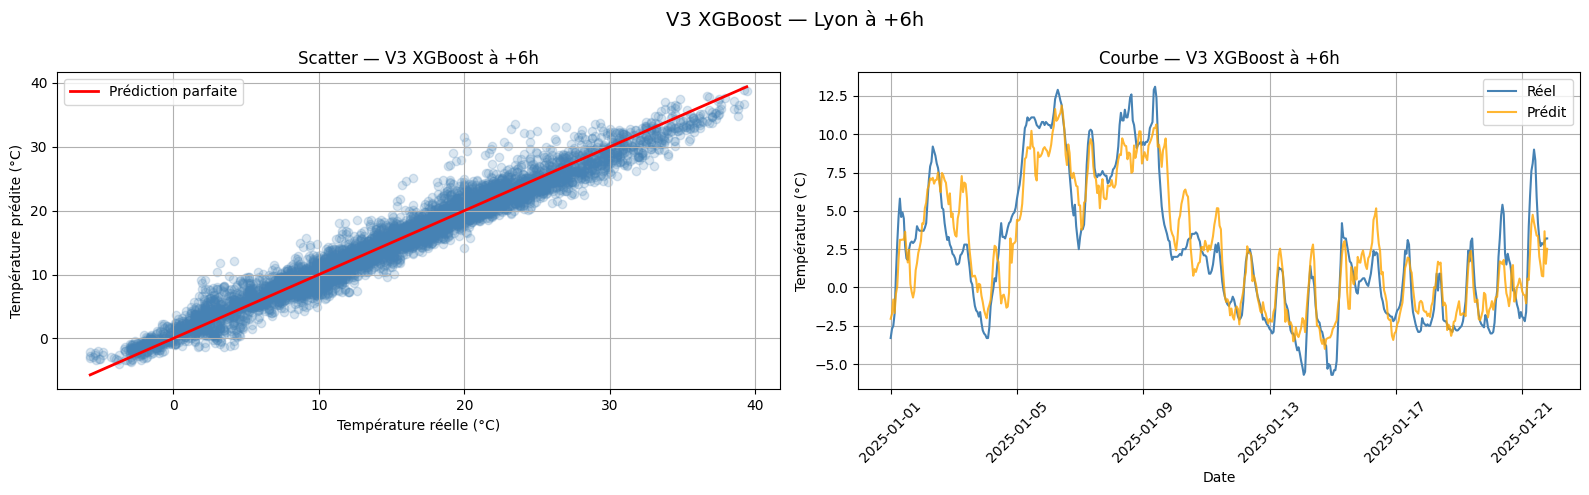

In [15]:
# ============================================================
# VERSION 3 — XGBOOST
# 200 arbres — learning_rate=0.1
# Plus puissant que le Random Forest
# Capture mieux les tendances complexes
# ============================================================

# --- Entraînement ---
modeles_v3 = entrainer_modeles(
    XGBRegressor,
    {
        "n_estimators" : 200,
        "learning_rate": 0.1,
        "max_depth"    : 6,
        "n_jobs"       : -1,
        "random_state" : 42,
        "verbosity"    : 0
    },
    X_train, df_final, split_train,
    "XGBoost"
)

# --- Validation ---
resultats_v3_val = evaluer_modeles(
    modeles_v3, X_val, df_final,
    split_train, split_validation,
    "V3 — XGBoost — Validation"
)

# --- Test final ---
resultats_v3_test = evaluer_modeles(
    modeles_v3, X_test, df_final,
    split_validation, None,
    "V3 — XGBoost — Test Final"
)

# --- Graphique ---
visualiser_modele(
    modeles_v3, df_final, features,
    split_train, split_validation, 6,
    "V3 XGBoost"
)

Version                     R² +1h   R² +2h   R² +3h   R² +4h   R² +5h   R² +6h
---------------------------------------------------------------------------
V1 — Régression Linéaire     0.969    0.935    0.895    0.857    0.824    0.802
V2 — Random Forest           0.975    0.956    0.937    0.919    0.902    0.882
V3 — XGBoost                 0.977    0.960    0.943    0.925    0.908    0.891


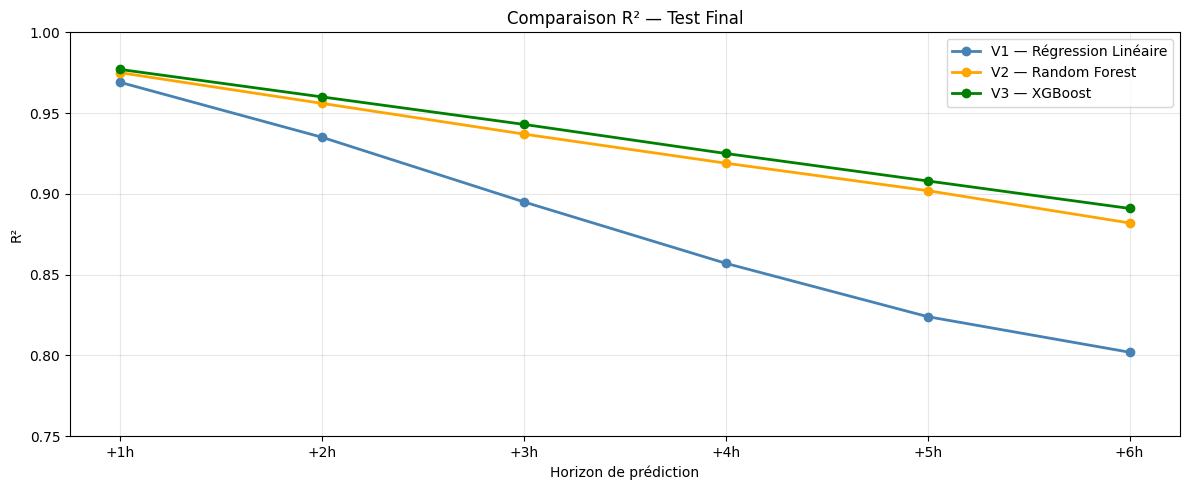


=== MODÈLE RETENU ===
V3 — XGBoost
Meilleur sur tous les horizons (+1h à +6h)
R² à +6h : 0.891 → Confiance : 89.1%


In [16]:
# ============================================================
# COMPARAISON DE TOUTES LES VERSIONS
# Scores extraits automatiquement des résultats
# ============================================================

# --- Historique construit automatiquement ---
historique_scores = {
    "V1 — Régression Linéaire" : resultats_v1_test,
    "V2 — Random Forest"       : resultats_v2_test,
    "V3 — XGBoost"             : resultats_v3_test,
}

# --- Tableau comparatif ---
print(f"{'Version':<25} {'R² +1h':>8} {'R² +2h':>8} {'R² +3h':>8} {'R² +4h':>8} {'R² +5h':>8} {'R² +6h':>8}")
print("-" * 75)
for version, scores in historique_scores.items():
    print(f"{version:<25} "
          f"{scores[1]['R2']:>8.3f} {scores[2]['R2']:>8.3f} {scores[3]['R2']:>8.3f} "
          f"{scores[4]['R2']:>8.3f} {scores[5]['R2']:>8.3f} {scores[6]['R2']:>8.3f}")

# --- Graphique comparatif ---
horizons = [f"+{h}h" for h in range(1, 7)]
couleurs = ["steelblue", "orange", "green"]

plt.figure(figsize=(12, 5))
for (version, scores), couleur in zip(historique_scores.items(), couleurs):
    valeurs = [scores[h]["R2"] for h in range(1, 7)]
    plt.plot(horizons, valeurs, marker="o",
             label=version, color=couleur, linewidth=2)

plt.title("Comparaison R² — Test Final")
plt.xlabel("Horizon de prédiction")
plt.ylabel("R²")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.75, 1.0)
plt.tight_layout()
plt.show()

# --- Conclusion ---
print("\n=== MODÈLE RETENU ===")
print("V3 — XGBoost")
print("Meilleur sur tous les horizons (+1h à +6h)")
print(f"R² à +6h : {resultats_v3_test[6]['R2']:.3f} → Confiance : {resultats_v3_test[6]['R2']*100:.1f}%")


Prévisions pour Lyon
Basées sur les données de : 17/03/2026 17h
----------------------------------------
Heure         Température  Confiance
----------------------------------------
17/03 18h          11.4°C      97.7%
17/03 19h           9.5°C      96.0%
17/03 20h           8.4°C      94.3%
17/03 21h           6.9°C      92.5%
17/03 22h           7.0°C      90.8%
17/03 23h           5.5°C      89.1%


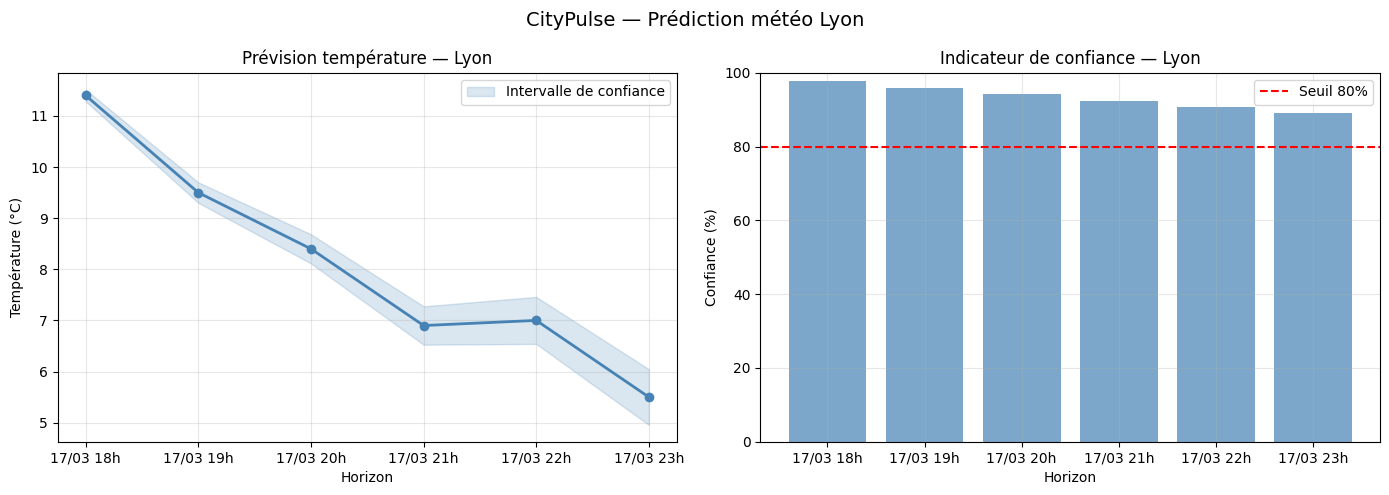


=== JSON pour l'endpoint ===
{
  "ville": "Lyon",
  "base": "17/03/2026 17h",
  "previsions": [
    {
      "heure": "17/03 18h",
      "temperature": 11.4,
      "confiance": 97.7
    },
    {
      "heure": "17/03 19h",
      "temperature": 9.5,
      "confiance": 96.0
    },
    {
      "heure": "17/03 20h",
      "temperature": 8.4,
      "confiance": 94.3
    },
    {
      "heure": "17/03 21h",
      "temperature": 6.9,
      "confiance": 92.5
    },
    {
      "heure": "17/03 22h",
      "temperature": 7.0,
      "confiance": 90.8
    },
    {
      "heure": "17/03 23h",
      "temperature": 5.5,
      "confiance": 89.1
    }
  ]
}


In [17]:
# ============================================================
# PRÉDICTION 6H + INDICATEUR DE CONFIANCE
# Modèle retenu : XGBoost V3
# Confiance extraite automatiquement des résultats
# ============================================================

# --- R² extrait automatiquement ---
r2_par_horizon = {h: resultats_v3_test[h]["R2"] for h in range(1, 7)}

# --- Prédiction pour une ville ---
VILLE = "Lyon"   # ← change ici pour tester une autre ville

resultat = predire_6h(modeles_v3, df_final, features, VILLE, r2_par_horizon)

# --- Affichage texte ---
print(f"\nPrévisions pour {resultat['ville']}")
print(f"Basées sur les données de : {resultat['base']}")
print("-" * 40)
print(f"{'Heure':<12} {'Température':>12} {'Confiance':>10}")
print("-" * 40)
for p in resultat["previsions"]:
    print(f"{p['heure']:<12} {p['temperature']:>10.1f}°C {p['confiance']:>9.1f}%")

# --- Graphique ---
heures     = [p["heure"]       for p in resultat["previsions"]]
temps      = [p["temperature"] for p in resultat["previsions"]]
confiances = [p["confiance"]   for p in resultat["previsions"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe température
axes[0].plot(heures, temps, marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(heures,
                     [t - (1 - c/100) * 5 for t, c in zip(temps, confiances)],
                     [t + (1 - c/100) * 5 for t, c in zip(temps, confiances)],
                     alpha=0.2, color="steelblue", label="Intervalle de confiance")
axes[0].set_title(f"Prévision température — {VILLE}")
axes[0].set_ylabel("Température (°C)")
axes[0].set_xlabel("Horizon")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Courbe confiance
axes[1].bar(heures, confiances, color="steelblue", alpha=0.7)
axes[1].set_title(f"Indicateur de confiance — {VILLE}")
axes[1].set_ylabel("Confiance (%)")
axes[1].set_xlabel("Horizon")
axes[1].set_ylim(0, 100)
axes[1].axhline(y=80, color="red", linestyle="--", label="Seuil 80%")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"CityPulse — Prédiction météo {VILLE}", fontsize=14)
plt.tight_layout()
plt.show()

# --- Export JSON pour l'endpoint ---
print("\n=== JSON pour l'endpoint ===")
print(json.dumps(resultat, indent=2, ensure_ascii=False))

In [18]:
# ============================================================
# SAUVEGARDE DES MODÈLES
# Les modèles sont sauvegardés en .pkl pour être utilisés
# par le backend sans réentraînement
# ============================================================

# --- Créer le dossier models/ ---
os.makedirs("models", exist_ok=True)

# --- Sauvegarder les 6 modèles XGBoost ---
for h in range(1, 7):
    chemin = f"models/modele_xgb_{h}h.pkl"
    with open(chemin, "wb") as f:
        pickle.dump(modeles_v3[h], f)
    print(f"✓ modele_xgb_{h}h.pkl sauvegardé")

# --- Sauvegarder la liste des features ---
with open("models/features.pkl", "wb") as f:
    pickle.dump(features, f)
print("✓ features.pkl sauvegardé")

# --- Sauvegarder les scores R² ---
with open("models/r2_par_horizon.pkl", "wb") as f:
    pickle.dump({h: resultats_v3_test[h]["R2"] for h in range(1, 7)}, f)
print("✓ r2_par_horizon.pkl sauvegardé")

# --- Vérifier les fichiers créés ---
print("\nFichiers sauvegardés :")
for fichier in os.listdir("models"):
    taille = os.path.getsize(f"models/{fichier}") / 1024
    print(f"  {fichier:<30} {taille:.1f} Ko")

✓ modele_xgb_1h.pkl sauvegardé
✓ modele_xgb_2h.pkl sauvegardé
✓ modele_xgb_3h.pkl sauvegardé
✓ modele_xgb_4h.pkl sauvegardé
✓ modele_xgb_5h.pkl sauvegardé
✓ modele_xgb_6h.pkl sauvegardé
✓ features.pkl sauvegardé
✓ r2_par_horizon.pkl sauvegardé

Fichiers sauvegardés :
  features.pkl                   0.3 Ko
  modele_xgb_1h.pkl              920.0 Ko
  modele_xgb_2h.pkl              931.5 Ko
  modele_xgb_3h.pkl              934.9 Ko
  modele_xgb_4h.pkl              930.2 Ko
  modele_xgb_5h.pkl              904.0 Ko
  modele_xgb_6h.pkl              918.2 Ko
  r2_par_horizon.pkl             0.1 Ko


In [19]:
# --- Charger les 6 modèles ---
modeles_charges = {}
for h in range(1, 7):
    with open(f"models/modele_xgb_{h}h.pkl", "rb") as f:
        modeles_charges[h] = pickle.load(f)

# --- Charger les features ---
with open("models/features.pkl", "rb") as f:
    features_charges = pickle.load(f)

# --- Charger les scores R² ---
with open("models/r2_par_horizon.pkl", "rb") as f:
    r2_charges = pickle.load(f)

print("Modèles chargés ✓")
print(f"Features : {features_charges}")
print(f"R²       : {r2_charges}")

Modèles chargés ✓
Features : ['temp_lag_1h', 'temp_lag_2h', 'temp_lag_3h', 'temp_lag_6h', 'temp_lag_12h', 'temp_lag_24h', 'temp_lag_36h', 'temp_lag_48h', 'temp_moy_6h', 'temp_moy_12h', 'temp_std_12h', 'humidite', 'pression', 'vent', 'nuages', 'heure_sin', 'heure_cos', 'mois_sin', 'mois_cos', 'ville_Bordeaux', 'ville_Lille', 'ville_Lyon', 'ville_Marseille', 'ville_Paris']
R²       : {1: 0.977, 2: 0.96, 3: 0.943, 4: 0.925, 5: 0.908, 6: 0.891}


In [20]:
# Faire une prédiction avec les modèles chargés
# (même résultat qu'avec les modèles entraînés)
resultat = predire_6h(
    modeles_charges,
    df_final,
    features_charges,
    "Lyon",
    r2_charges
)

print(json.dumps(resultat, indent=2, ensure_ascii=False))


{
  "ville": "Lyon",
  "base": "17/03/2026 17h",
  "previsions": [
    {
      "heure": "17/03 18h",
      "temperature": 11.4,
      "confiance": 97.7
    },
    {
      "heure": "17/03 19h",
      "temperature": 9.5,
      "confiance": 96.0
    },
    {
      "heure": "17/03 20h",
      "temperature": 8.4,
      "confiance": 94.3
    },
    {
      "heure": "17/03 21h",
      "temperature": 6.9,
      "confiance": 92.5
    },
    {
      "heure": "17/03 22h",
      "temperature": 7.0,
      "confiance": 90.8
    },
    {
      "heure": "17/03 23h",
      "temperature": 5.5,
      "confiance": 89.1
    }
  ]
}


In [21]:
# ============================================================
# DOCUMENTATION POUR LE BACKEND
# Ce que l'équipe backend doit savoir pour utiliser les modèles
# ============================================================

documentation = """
╔══════════════════════════════════════════════════════════════╗
║           DOCUMENTATION ML — CityPulse                      ║
║           Prédiction température 6h                         ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. MODÈLE RETENU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Algorithme  : XGBoost
  Fichiers    : models/modele_xgb_1h.pkl → modele_xgb_6h.pkl
  Features    : models/features.pkl
  Scores R²   : models/r2_par_horizon.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. PERFORMANCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Horizon  R²      MAE     Confiance
  +1h      0.977   0.56°C  97.7%
  +2h      0.960   0.73°C  96.0%
  +3h      0.943   0.88°C  94.3%
  +4h      0.925   1.02°C  92.5%
  +5h      0.908   1.13°C  90.8%
  +6h      0.891   1.24°C  89.1%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. DONNÉES REQUISES DEPUIS OPEN-METEO FORECAST API
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL : https://api.open-meteo.com/v1/forecast

  Paramètres obligatoires :
    - latitude, longitude
    - hourly : temperature_2m
    - hourly : relative_humidity_2m
    - hourly : surface_pressure
    - hourly : wind_speed_10m
    - hourly : cloud_cover
    - hourly : precipitation
    - past_hours : 48     ← IMPORTANT : 48h de passé requis
    - forecast_hours : 6
    - timezone : Europe/Paris

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. VILLES SUPPORTÉES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ville       Latitude   Longitude
  Lyon        45.7640    4.8357
  Paris       48.8566    2.3522
  Marseille   43.2965    5.3698
  Bordeaux    44.8378   -0.5792
  Lille       50.6292    3.0573

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. FEATURES À CONSTRUIRE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Lags température :
    temp_lag_1h  → température il y a 1h
    temp_lag_2h  → température il y a 2h
    temp_lag_3h  → température il y a 3h
    temp_lag_6h  → température il y a 6h
    temp_lag_12h → température il y a 12h
    temp_lag_24h → température il y a 24h
    temp_lag_36h → température il y a 36h
    temp_lag_48h → température il y a 48h

  Fenêtres glissantes :
    temp_moy_6h  → moyenne température 6 dernières heures
    temp_moy_12h → moyenne température 12 dernières heures
    temp_std_12h → écart-type température 12 dernières heures

  Variables météo actuelles :
    humidite  → relative_humidity_2m
    pression  → surface_pressure
    vent      → wind_speed_10m
    nuages    → cloud_cover

  Variables temporelles cycliques :
    heure_sin → sin(2π × heure / 24)
    heure_cos → cos(2π × heure / 24)
    mois_sin  → sin(2π × mois / 12)
    mois_cos  → cos(2π × mois / 12)

  Encodage ville (One-Hot) :
    ville_Bordeaux  → 1 si Bordeaux, 0 sinon
    ville_Lille     → 1 si Lille,    0 sinon
    ville_Lyon      → 1 si Lyon,     0 sinon
    ville_Marseille → 1 si Marseille,0 sinon
    ville_Paris     → 1 si Paris,    0 sinon

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. FORMAT DE SORTIE JSON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  {
    "ville"     : "Lyon",
    "base"      : "17/03/2026 17h",
    "previsions": [
      {"heure": "17/03 18h", "temperature": 11.4, "confiance": 97.7},
      {"heure": "17/03 19h", "temperature":  9.5, "confiance": 96.0},
      {"heure": "17/03 20h", "temperature":  8.4, "confiance": 94.3},
      {"heure": "17/03 21h", "temperature":  6.9, "confiance": 92.5},
      {"heure": "17/03 22h", "temperature":  7.0, "confiance": 90.8},
      {"heure": "17/03 23h", "temperature":  5.5, "confiance": 89.1}
    ]
  }

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. CODE D'INTÉGRATION BACKEND
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  import pickle

  # Charger les modèles au démarrage
  modeles = {}
  for h in range(1, 7):
      with open(f"models/modele_xgb_{h}h.pkl", "rb") as f:
          modeles[h] = pickle.load(f)

  with open("models/features.pkl", "rb") as f:
      features = pickle.load(f)

  with open("models/r2_par_horizon.pkl", "rb") as f:
      r2 = pickle.load(f)

  # Appeler à chaque requête
  resultat = predire_6h(modeles, df, features, ville, r2)
"""

print(documentation)

# --- Sauvegarder en fichier texte ---
with open("models/DOCUMENTATION.txt", "w", encoding="utf-8") as f:
    f.write(documentation)

print("Documentation sauvegardée : models/DOCUMENTATION.txt ✓")


╔══════════════════════════════════════════════════════════════╗
║           DOCUMENTATION ML — CityPulse                      ║
║           Prédiction température 6h                         ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. MODÈLE RETENU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Algorithme  : XGBoost
  Fichiers    : models/modele_xgb_1h.pkl → modele_xgb_6h.pkl
  Features    : models/features.pkl
  Scores R²   : models/r2_par_horizon.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. PERFORMANCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Horizon  R²      MAE     Confiance
  +1h      0.977   0.56°C  97.7%
  +2h      0.960   0.73°C  96.0%
  +3h      0.943   0.88°C  94.3%
  +4h      0.925   1.02°C  92.5%
  +5h      0.908   1.13°C  90.8%
  +6h      0.891   1.24°C  89.1%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.